* Here we are going to calculate the mutual information of dependent and independent variable.
* If those are having 0 it means they are not dependent if 1 they are highly dependent.
* The Mutual Information was calculated by the Entropy Estimation.
* Whichever the value having highest score is very important featue

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv('framingham.csv')

In [3]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
data.fillna(0,inplace = True)

In [6]:
datas = [ i for i in data.columns if data[i].dtype == 'float64']

In [7]:
datas # NOw this values are float values, we need to convert into integers

['education',
 'cigsPerDay',
 'BPMeds',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose']

In [8]:
data.education = [int(i) for i in data.education]

In [9]:
data.cigsPerDay = [int(i) for i in data.cigsPerDay]


In [10]:
data.BPMeds = [int(i) for i in data.BPMeds]

In [11]:
data.totChol = [int(i) for i in data.totChol]

In [12]:
data.sysBP = [int(i) for i in data.sysBP]

In [13]:
data.diaBP = [int(i) for i in data.diaBP]

In [14]:
data.BMI = [ int(i) for i in data.BMI]

In [15]:
data.heartRate = [ int(i) for i in data.heartRate]

In [16]:
data.glucose = [ int(i) for i in data.glucose]

In [17]:
# To avoid overfitting we use the train test split
from sklearn.model_selection import train_test_split

In [18]:
X = data.drop('TenYearCHD',axis = 1)
y = data['TenYearCHD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [19]:
from sklearn.feature_selection import mutual_info_classif

In [21]:
mutual_info = mutual_info_classif(X_train,y_train)

In [22]:
mutual_info

array([0.01208605, 0.02283711, 0.00613576, 0.00426976, 0.0028875 ,
       0.        , 0.01005002, 0.02374061, 0.00251928, 0.00159288,
       0.01958507, 0.        , 0.00597364, 0.00571626, 0.00221615])

<AxesSubplot:>

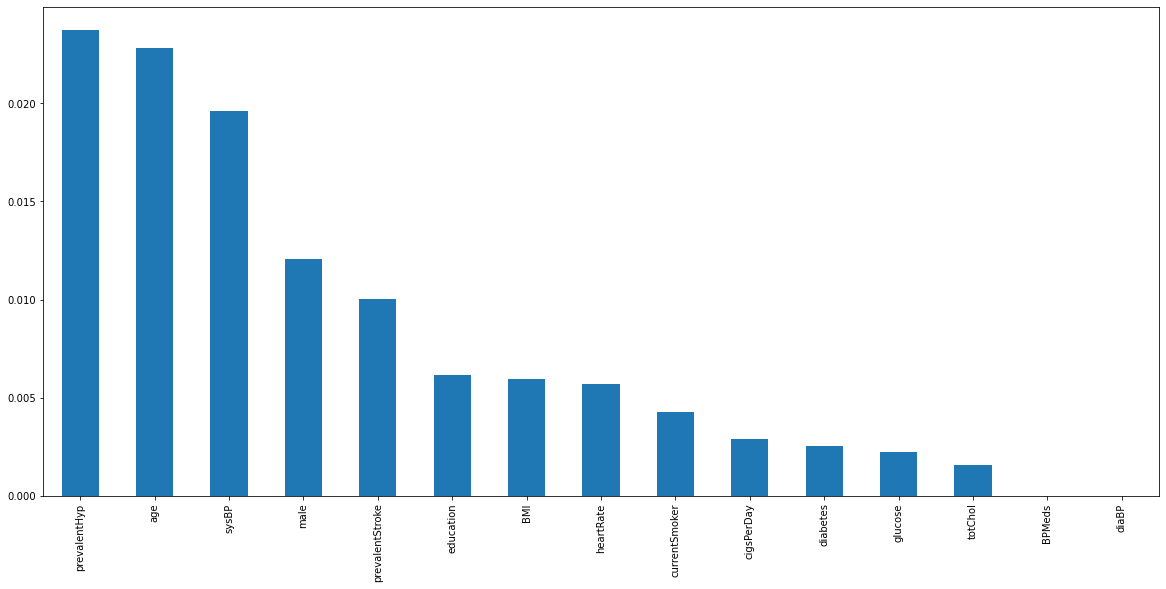

In [29]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
a = mutual_info.sort_values(ascending = False)
mutual_info.sort_values(ascending = False).plot.bar(figsize = (20,9))


In [30]:
a

prevalentHyp       0.023741
age                0.022837
sysBP              0.019585
male               0.012086
prevalentStroke    0.010050
education          0.006136
BMI                0.005974
heartRate          0.005716
currentSmoker      0.004270
cigsPerDay         0.002888
diabetes           0.002519
glucose            0.002216
totChol            0.001593
BPMeds             0.000000
diaBP              0.000000
dtype: float64

In [31]:
# now we can take the features using k methos

In [32]:
from sklearn.feature_selection import SelectKBest

In [34]:
sel = SelectKBest(mutual_info_classif, k = 6)
sel.fit(X_train,y_train)


SelectKBest(k=6,
            score_func=<function mutual_info_classif at 0x0000018D583E5828>)

In [38]:
X_train.columns[sel.get_support()] # this are all first 6 values

Index(['age', 'cigsPerDay', 'prevalentHyp', 'sysBP', 'BMI', 'heartRate'], dtype='object')

* Then we can do the model building with the features.